# Trilha A — Varredura de K (K-Sweep)

Avalia o impacto da quantidade de features selecionadas pelo SelectKBest no desempenho final no teste.

Para cada valor de K em `K_SWEEP`:
1. Executa k-fold em todos os 22 modelos × 3 datasets com aquele K
2. Elege o melhor modelo por AUC médio no k-fold (pode ser diferente a cada K)
3. Retreina o vencedor no trainval completo
4. Avalia no test set fixo

Isso garante que o modelo selecionado é sempre o mais adequado para cada quantidade de features,
evitando o viés de fixar um modelo treinado com K diferente.

## Env Configuration

Importações, caminhos, parâmetros globais e definição dos valores de K a varrer.

In [ ]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data', 'images', 'datasets')
MODULES_DIR  = os.path.join(PROJECT_ROOT, 'modules')
OUTPUT_DIR   = os.path.join(PROJECT_ROOT, 'experiments', 'trilha_a_k_sweep')

if MODULES_DIR not in sys.path:
    sys.path.insert(0, MODULES_DIR)

from models import ALL_CLASSIFIERS, build_selectkbest_pipeline
from evaluation import (
    META_COLS, DATASETS, compute_metrics, aggregate_folds, run_kfold,
    youden_threshold, evaluate_at_threshold,
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

K_SWEEP  = [5, 10, 15, 20, 30, 50, 100, 'all']
N_FOLDS  = 5
VAL_SIZE = 0.20
SEED     = 42

sns.set_theme(style='whitegrid', font_scale=1.0, rc={
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.alpha': 0.3,
    'font.family': 'sans-serif',
})

PASTEL_COLORS = {
    'BW':         '#A3C4F3',
    'Doppler':    '#80CED7',
    'BW+Doppler': '#C3AED6',
}
ACCENT_COLORS = {
    'BW':         '#5B8DB8',
    'Doppler':    '#4A9EA6',
    'BW+Doppler': '#8B6FB0',
}
DS_COLORS = PASTEL_COLORS

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'OUTPUT_DIR   : {OUTPUT_DIR}')
print(f'K_SWEEP      : {K_SWEEP}')
print(f'N_FOLDS      : {N_FOLDS}')
print(f'Classificadores: {len(ALL_CLASSIFIERS)}')
print(f'Datasets       : {list(DATASETS.keys())}')

## Functions

`build_selectkbest_pipeline` (de `modules/models.py`) já suporta `k='all'` para pular o SelectKBest.
`youden_threshold` e `evaluate_at_threshold` vêm de `modules/evaluation.py`.

## Process

Pipeline completo da varredura de K:
1. Carrega os 3 datasets radiômicos
2. Para cada K: executa k-fold em todos os modelos × datasets, elege vencedor por AUC médio
3. Retreina vencedor no trainval completo com aquele K
4. Avalia no test set (threshold=0.5 e Youden)
5. Salva resultados e gera visualizações

### 1. Carga dos datasets

In [3]:
dfs = {}
for ds_name, ds_file in DATASETS.items():
    df = pd.read_csv(os.path.join(DATA_DIR, ds_file))
    dfs[ds_name] = df
    feat_cols = [c for c in df.columns if c not in META_COLS]
    trainval  = df[df['split'] == 'trainval']
    test      = df[df['split'] == 'test']
    print(f'=== {ds_name} ===')
    print(f'  trainval: {len(trainval)} | test: {len(test)} | features: {len(feat_cols)}')
    print(f'  Benigno={int((trainval["target"]==0).sum())} | Maligno={int((trainval["target"]==1).sum())}')
    print()

=== BW ===
  trainval: 178 | test: 20 | features: 465
  Benigno=118 | Maligno=60



=== Doppler ===
  trainval: 178 | test: 20 | features: 465
  Benigno=118 | Maligno=60



=== BW+Doppler ===
  trainval: 178 | test: 20 | features: 930
  Benigno=118 | Maligno=60



### 2. Varredura de K — k-fold + eleição do vencedor + avaliação no teste

In [ ]:
clf_map      = dict(ALL_CLASSIFIERS)
sweep_rows   = []   # uma linha por (K, dataset): vencedor + métricas no teste
kfold_rows   = []   # todas as configs (K, dataset, modelo) com AUC kfold

start_time = datetime.now()

for k in K_SWEEP:
    print(f'\n{"="*60}')
    print(f'K = {k}')
    print(f'{"="*60}')

    for ds_name, df in dfs.items():
        feat_cols = [c for c in df.columns if c not in META_COLS]
        trainval  = df[df['split'] == 'trainval']
        test      = df[df['split'] == 'test']

        X_tv = trainval[feat_cols].values.astype(float)
        y_tv = trainval['target'].values
        X_te = test[feat_cols].values.astype(float)
        y_te = test['target'].values

        k_eff = X_tv.shape[1] if k == 'all' else min(k, X_tv.shape[1])
        k_label = 'all' if k == 'all' else k_eff

        # --- k-fold em todos os modelos ---
        agg_results = []
        for clf_name, clf in ALL_CLASSIFIERS:
            try:
                pipe         = build_selectkbest_pipeline(clone(clf), k_eff if k != 'all' else 'all')
                fold_results = run_kfold(X_tv, y_tv, pipe, n_folds=N_FOLDS, seed=SEED)
                agg          = aggregate_folds(fold_results)
                agg_results.append({'model': clf_name, **agg})
                kfold_rows.append({
                    'k': k_label, 'dataset': ds_name,
                    'model': clf_name, **agg,
                })
            except Exception as e:
                agg_results.append({'model': clf_name, 'auc_mean': float('nan')})

        # --- elege vencedor por AUC médio ---
        df_agg     = pd.DataFrame(agg_results).dropna(subset=['auc_mean'])
        best_row   = df_agg.loc[df_agg['auc_mean'].idxmax()]
        best_model = best_row['model']
        best_kfold_auc = best_row['auc_mean']

        print(f'  {ds_name:<12} vencedor k-fold: {best_model:<35} AUC={best_kfold_auc:.3f}', end=' ')

        # --- treino final no trainval completo ---
        X_tr, X_val, y_tr, y_val = train_test_split(
            X_tv, y_tv, test_size=VAL_SIZE, stratify=y_tv, random_state=SEED
        )

        pipe_final = build_selectkbest_pipeline(clone(clf_map[best_model]), k_eff if k != 'all' else 'all')
        pipe_final.fit(X_tv, y_tv)

        prob_val  = pipe_final.predict_proba(X_val)[:, 1]
        prob_test = pipe_final.predict_proba(X_te)[:, 1]

        thr_youden  = youden_threshold(y_val, prob_val)
        test_05     = evaluate_at_threshold(y_te, prob_test, 0.5)
        test_youden = evaluate_at_threshold(y_te, prob_test, thr_youden)

        sweep_rows.append({
            'k':               k_label,
            'k_numeric':       X_tv.shape[1] if k == 'all' else k_eff,
            'dataset':         ds_name,
            'best_model':      best_model,
            'kfold_auc_mean':  best_kfold_auc,
            'kfold_auc_std':   best_row.get('auc_std', float('nan')),
            'threshold_youden': thr_youden,
            'test_auc':        test_05['auc'],
            'test_accuracy':   test_05['accuracy'],
            'test_sens':       test_05['sensitivity'],
            'test_spec':       test_05['specificity'],
            'test_f1':         test_05['f1'],
            'test_auc_youden':  test_youden['auc'],
            'test_sens_youden': test_youden['sensitivity'],
            'test_spec_youden': test_youden['specificity'],
        })

        print(f'→ teste AUC={test_05["auc"]:.3f}')

elapsed = (datetime.now() - start_time).seconds
print(f'\nConcluído em {elapsed}s')

df_sweep = pd.DataFrame(sweep_rows)
df_kfold = pd.DataFrame(kfold_rows)

### 3. Salvar resultados

In [5]:
sweep_csv = os.path.join(OUTPUT_DIR, 'k_sweep_results.csv')
kfold_csv = os.path.join(OUTPUT_DIR, 'k_sweep_kfold_all.csv')

df_sweep.to_csv(sweep_csv, index=False)
df_kfold.to_csv(kfold_csv, index=False)

print(f'Resultados por K (vencedor + teste) → {sweep_csv}  ({len(df_sweep)} linhas)')
print(f'K-fold completo (todos modelos)     → {kfold_csv}  ({len(df_kfold)} linhas)')
print()

display(
    df_sweep[['k', 'dataset', 'best_model', 'kfold_auc_mean', 'test_auc', 'test_sens', 'test_spec']]
    .style.format({
        'kfold_auc_mean': '{:.3f}',
        'test_auc':       '{:.3f}',
        'test_sens':      '{:.3f}',
        'test_spec':      '{:.3f}',
    })
    .background_gradient(subset=['test_auc'], cmap='RdYlGn')
)

Resultados por K (vencedor + teste) → /Users/lucasgambim/Documents/TCC-PROJECT/experiments/trilha_a_k_sweep/k_sweep_results.csv  (24 linhas)
K-fold completo (todos modelos)     → /Users/lucasgambim/Documents/TCC-PROJECT/experiments/trilha_a_k_sweep/k_sweep_kfold_all.csv  (519 linhas)



,k,dataset,best_model,kfold_auc_mean,test_auc,test_sens,test_spec
0,5,BW,Medium KNN,0.730,0.830,0.714,1.000
1,5,Doppler,Weighted KNN,0.821,0.923,0.571,0.923
2,5,BW+Doppler,Medium Gaussian SVM,0.806,0.824,0.714,1.000
3,10,BW,Weighted KNN,0.751,0.846,0.571,0.923
4,10,Doppler,Weighted KNN,0.833,0.956,0.571,0.923
5,10,BW+Doppler,Cosine KNN,0.814,0.912,0.571,0.923
6,15,BW,Medium Gaussian SVM,0.762,0.923,0.714,1.000
7,15,Doppler,Weighted KNN,0.826,0.934,0.571,0.846
8,15,BW+Doppler,Linear Discriminant Analysis,0.815,0.934,0.714,1.000
9,20,BW,Medium Gaussian SVM,0.755,0.901,0.714,1.000


### 4. Visualização — AUC no teste por K (scatter do melhor modelo) e AUC validação cruzada (boxplot)

In [ ]:
from matplotlib.lines import Line2D

fig, (ax_scat, ax_box) = plt.subplots(1, 2, figsize=(18, 6))

k_order_str = [str(k) for k in K_SWEEP]
df_sweep['k_str'] = df_sweep['k'].astype(str)
df_kfold['k_str'] = df_kfold['k'].astype(str)

all_n = int(df_sweep.loc[df_sweep['k_str'] == 'all', 'k_numeric'].iloc[0])

# --- Esquerda: scatter de AUC no teste (melhor modelo por K e dataset) ---
for ds_name in DATASETS.keys():
    sub = df_sweep[df_sweep['dataset'] == ds_name].copy()
    sub['xi'] = sub['k_str'].apply(lambda x: k_order_str.index(x))

    ax_scat.scatter(sub['xi'], sub['test_auc'],
                    color=ACCENT_COLORS[ds_name], s=70, zorder=3, label=ds_name)

    for _, row in sub.iterrows():
        ax_scat.annotate(
            row['best_model'][:16],
            (row['xi'], row['test_auc']),
            textcoords='offset points', xytext=(0, 8),
            fontsize=6, ha='center', color=ACCENT_COLORS[ds_name],
        )

ax_scat.set_xticks(range(len(k_order_str)))
ax_scat.set_xticklabels(
    [k if k != 'all' else f'all\n({all_n})' for k in k_order_str], fontsize=8
)
ax_scat.set_xlabel('Número de features (K)', fontsize=10)
ax_scat.set_ylabel('AUC no Teste', fontsize=10)
ax_scat.set_title('Teste — AUC do melhor modelo por K', fontsize=11, fontweight='bold')
ax_scat.set_ylim(0.4, 1.05)
ax_scat.axhline(0.5, color='#CCCCCC', linestyle='--', linewidth=0.8, alpha=0.6)
ax_scat.legend(title='Dataset', fontsize=9, title_fontsize=9)

# --- Direita: boxplot de AUC da validação cruzada (todos os modelos) ---
palette = {ds: PASTEL_COLORS[ds] for ds in DATASETS}

sns.boxplot(
    data=df_kfold,
    x='k_str', y='auc_mean', hue='dataset',
    order=k_order_str,
    hue_order=list(DATASETS.keys()),
    palette=palette,
    width=0.6, linewidth=1.2,
    flierprops=dict(marker='o', markersize=3, alpha=0.5),
    ax=ax_box,
)

# Marca o vencedor (★) dentro de cada caixa
ds_list  = list(DATASETS.keys())
n_hue    = len(ds_list)
step     = 0.6 / n_hue
offsets  = [step * (i - (n_hue - 1) / 2) for i in range(n_hue)]

for _, row in df_sweep.iterrows():
    xi     = k_order_str.index(str(row['k']))
    ds_idx = ds_list.index(row['dataset'])
    ax_box.plot(xi + offsets[ds_idx], row['kfold_auc_mean'],
                marker='*', color=ACCENT_COLORS[row['dataset']],
                markersize=11, zorder=5, linestyle='none')

ax_box.set_xticks(range(len(k_order_str)))
ax_box.set_xticklabels(
    [k if k != 'all' else f'all\n({all_n})' for k in k_order_str], fontsize=8
)
ax_box.set_xlabel('Número de features (K)', fontsize=10)
ax_box.set_ylabel('AUC Médio (K-Fold)', fontsize=10)
ax_box.set_title('Validação Cruzada — distribuição de AUC  (★ = vencedor eleito)',
                 fontsize=11, fontweight='bold')
ax_box.set_ylim(0.3, 1.05)
ax_box.axhline(0.5, color='#CCCCCC', linestyle='--', linewidth=0.8, alpha=0.6)
ax_box.legend(title='Dataset', fontsize=9, title_fontsize=9)

plt.tight_layout()
out_png = os.path.join(OUTPUT_DIR, 'k_sweep_auc_line.png')
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo: {out_png}')

### 5. Visualização — Sens e Spec no teste por K

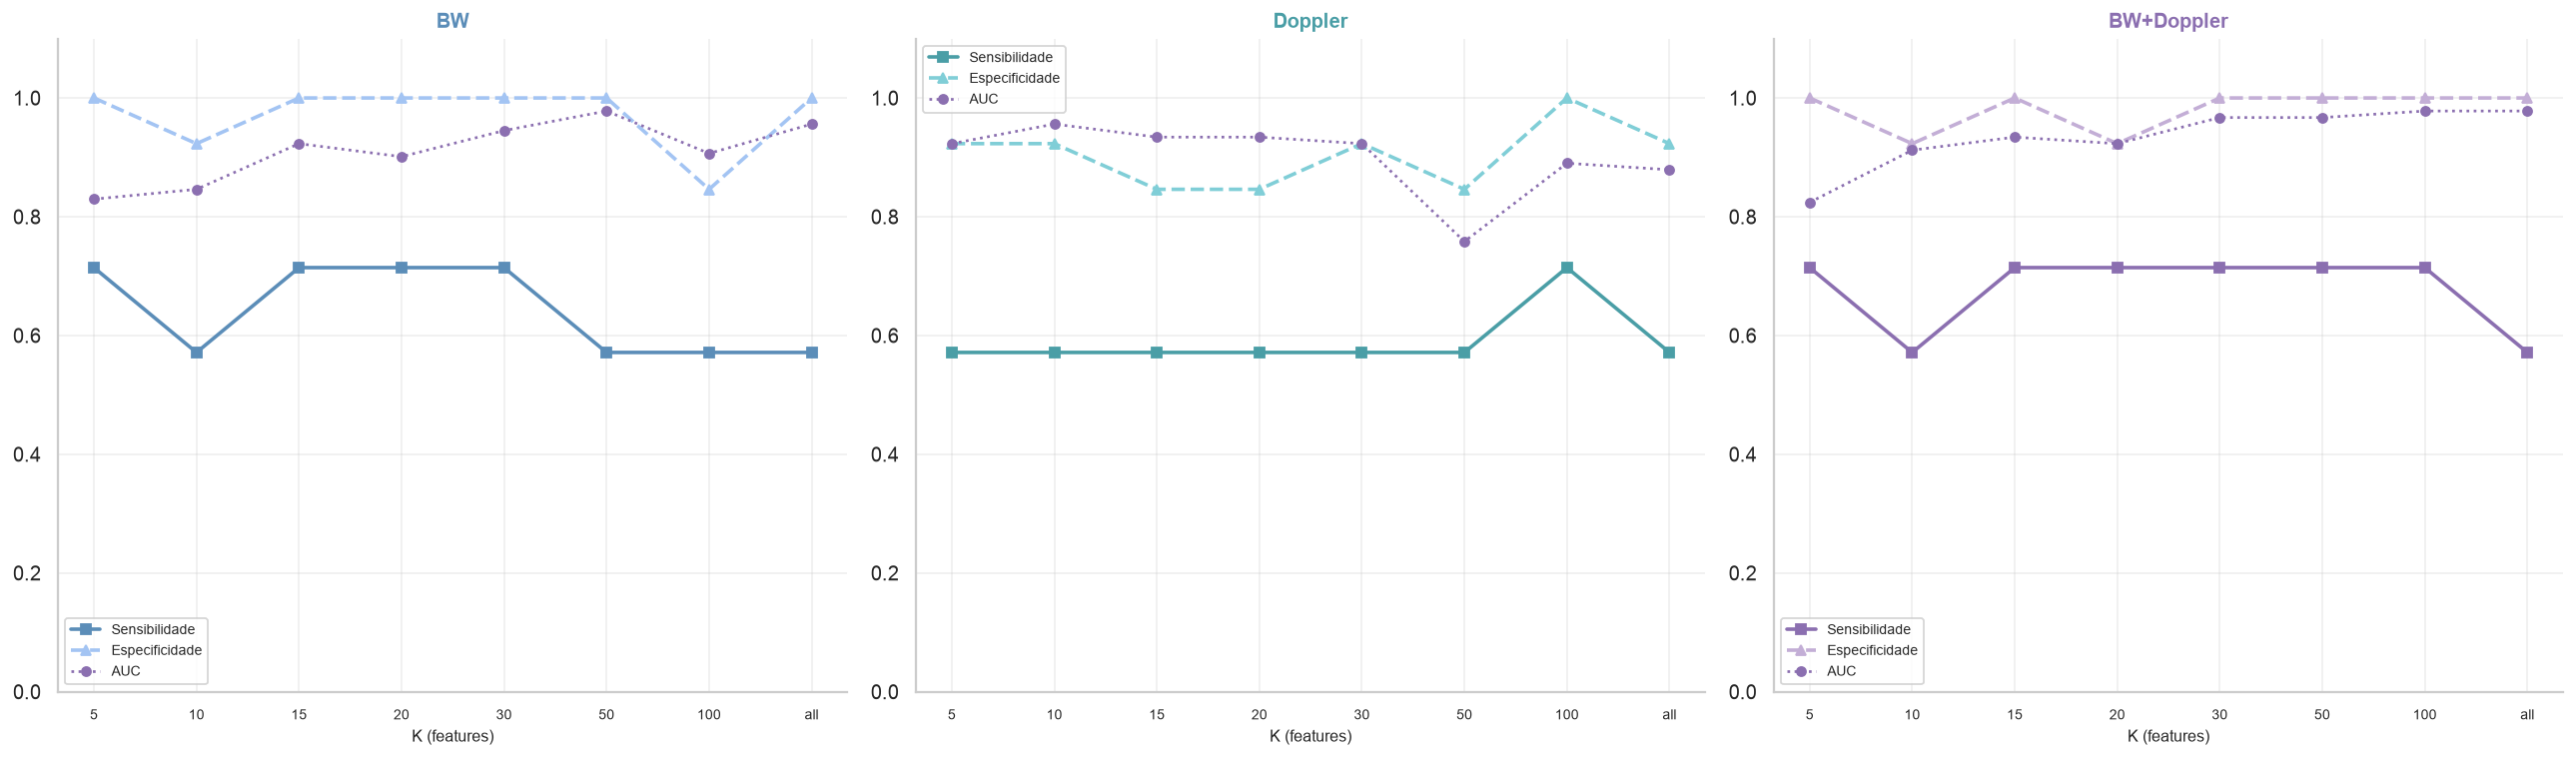

Salvo: /Users/lucasgambim/Documents/TCC-PROJECT/experiments/trilha_a_k_sweep/k_sweep_sens_spec.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, ds_name in zip(axes, DATASETS.keys()):
    accent = ACCENT_COLORS[ds_name]
    pastel = PASTEL_COLORS[ds_name]
    sub    = df_sweep[df_sweep['dataset'] == ds_name].sort_values('k_numeric')
    x_labels = [str(k) for k in sub['k'].tolist()]
    x_pos    = range(len(x_labels))

    ax.plot(x_pos, sub['test_sens'], marker='s', label='Sensibilidade',
            color=accent, linewidth=2, markersize=6)
    ax.plot(x_pos, sub['test_spec'], marker='^', label='Especificidade',
            color=pastel, linewidth=2, markersize=6, linestyle='--')
    ax.plot(x_pos, sub['test_auc'],  marker='o', label='AUC',
            color='#8B6FB0', linewidth=1.5, markersize=5, linestyle=':')

    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, fontsize=8)
    ax.set_xlabel('K (features)', fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_title(ds_name, fontsize=11, fontweight='bold', color=accent)
    ax.legend(fontsize=8)

plt.tight_layout()
out_png = os.path.join(OUTPUT_DIR, 'k_sweep_sens_spec.png')
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo: {out_png}')

### 6. Visualização — Modelo vencedor por K e dataset

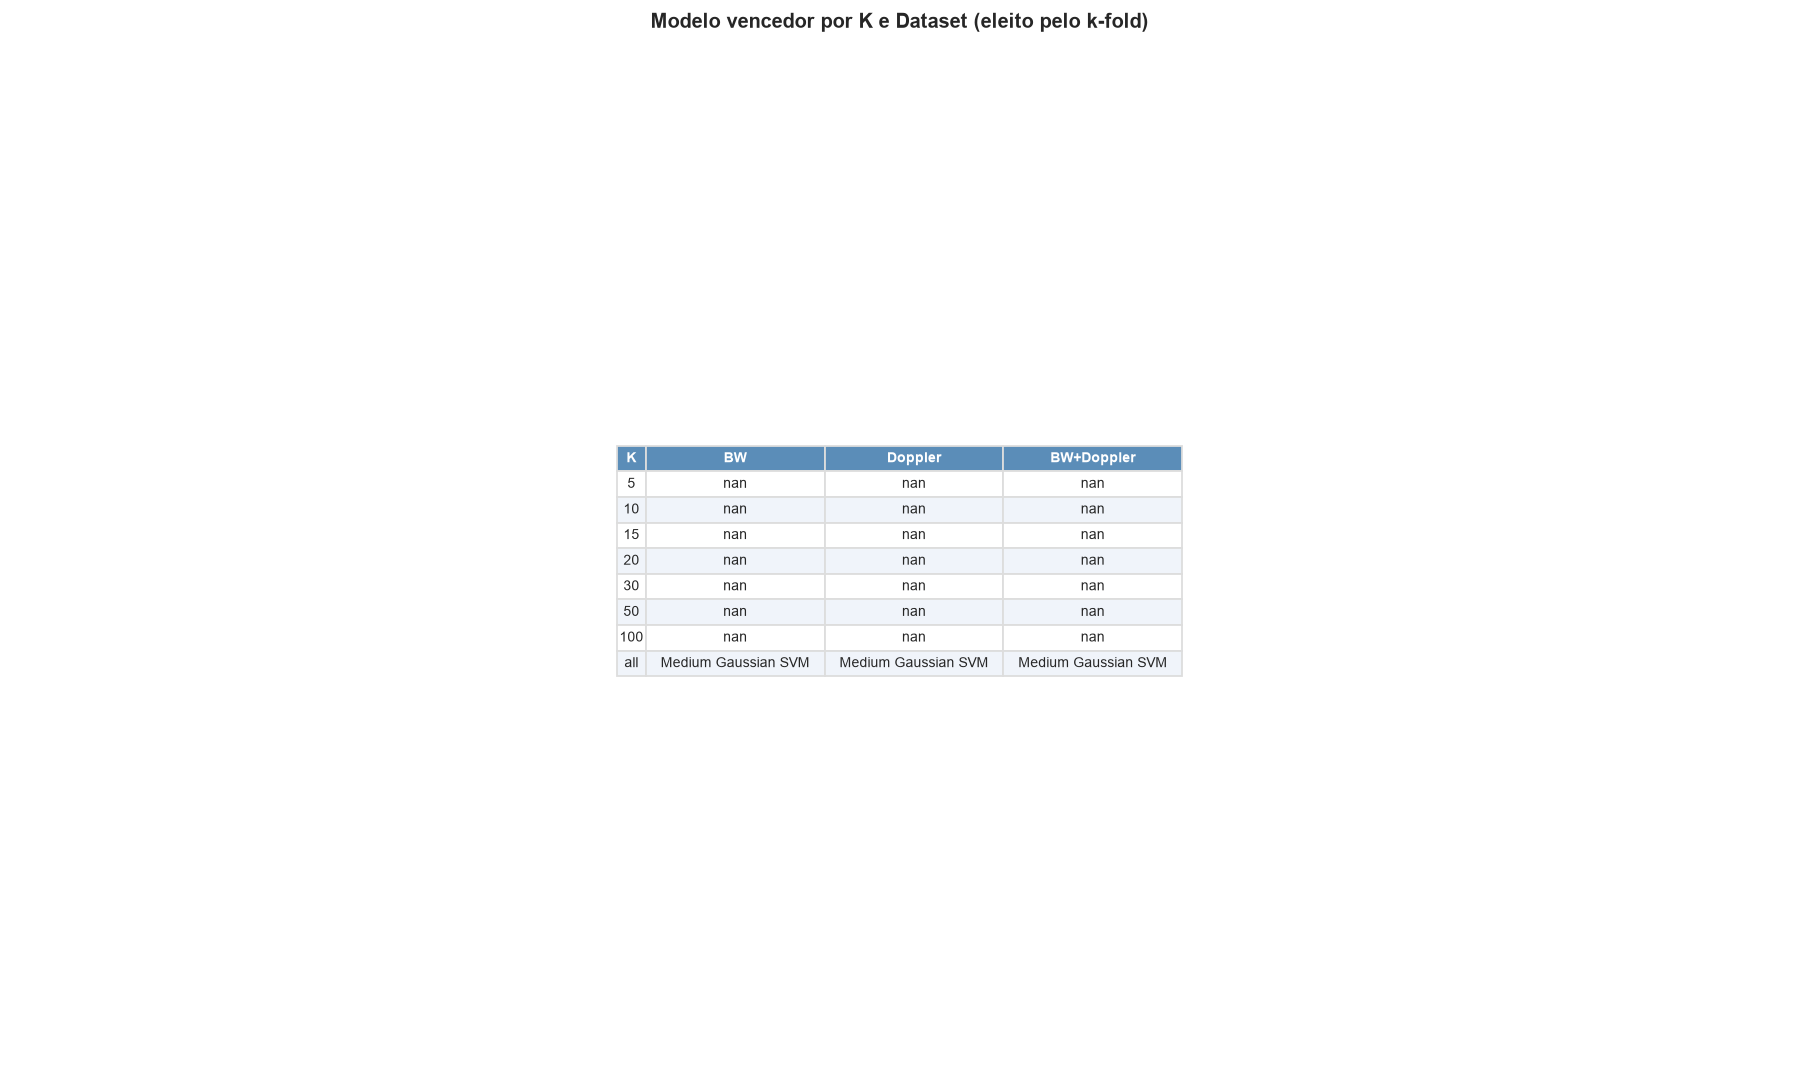

Salvo: /Users/lucasgambim/Documents/TCC-PROJECT/experiments/trilha_a_k_sweep/k_sweep_winner_table.png


In [8]:
pivot = df_sweep.pivot(index='k', columns='dataset', values='best_model')
k_order = [str(k) for k in K_SWEEP]
pivot = pivot.reindex([k for k in k_order if k in pivot.index.astype(str)])

fig, ax = plt.subplots(figsize=(14, len(pivot) * 0.8 + 2))
ax.axis('off')

col_labels = ['K'] + list(DATASETS.keys())
cell_data  = [[str(idx)] + [pivot.loc[idx, ds] if ds in pivot.columns else '-'
               for ds in DATASETS.keys()]
              for idx in pivot.index]

table = ax.table(
    cellText=cell_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.auto_set_column_width(range(len(col_labels)))

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#5B8DB8')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#F0F4FA')
    cell.set_edgecolor('#DDDDDD')

ax.set_title('Modelo vencedor por K e Dataset (eleito pelo k-fold)',
             fontsize=11, fontweight='bold', pad=20)

plt.tight_layout()
out_png = os.path.join(OUTPUT_DIR, 'k_sweep_winner_table.png')
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo: {out_png}')

### 7. Sumário final

In [9]:
print('=' * 90)
print('TRILHA A — K-SWEEP  SUMÁRIO FINAL')
print('=' * 90)

for ds_name in DATASETS:
    sub = df_sweep[df_sweep['dataset'] == ds_name].sort_values('k_numeric')
    print(f'\nDataset: {ds_name}')
    print(f"  {'K':<6} {'Modelo vencedor':<35} {'KFold AUC':>10} {'Test AUC':>9} {'Sens':>7} {'Spec':>7} {'F1':>7}")
    print(f"  {'-'*6} {'-'*35} {'-'*10} {'-'*9} {'-'*7} {'-'*7} {'-'*7}")
    for _, row in sub.iterrows():
        print(f"  {str(row['k']):<6} {row['best_model']:<35} "
              f"{row['kfold_auc_mean']:>8.3f}±{row['kfold_auc_std']:.2f}  "
              f"{row['test_auc']:>8.3f}  "
              f"{row['test_sens']:>6.3f}  "
              f"{row['test_spec']:>6.3f}  "
              f"{row['test_f1']:>6.3f}")

print(f'\nArquivos salvos em: {OUTPUT_DIR}')
for f in sorted(os.listdir(OUTPUT_DIR)):
    size_kb = os.path.getsize(os.path.join(OUTPUT_DIR, f)) // 1024
    print(f'  {f:<50} {size_kb} KB')

TRILHA A — K-SWEEP  SUMÁRIO FINAL

Dataset: BW
  K      Modelo vencedor                      KFold AUC  Test AUC    Sens    Spec      F1
  ------ ----------------------------------- ---------- --------- ------- ------- -------
  5      Medium KNN                             0.730±0.05     0.830   0.714   1.000   0.833
  10     Weighted KNN                           0.751±0.08     0.846   0.571   0.923   0.667
  15     Medium Gaussian SVM                    0.762±0.08     0.923   0.714   1.000   0.833
  20     Medium Gaussian SVM                    0.755±0.07     0.901   0.714   1.000   0.833
  30     Subspace Discriminant                  0.754±0.09     0.945   0.714   1.000   0.833
  50     Subspace Discriminant                  0.756±0.08     0.978   0.571   1.000   0.727
  100    Bagged Trees                           0.763±0.08     0.907   0.571   0.846   0.615
  all    Medium Gaussian SVM                    0.774±0.07     0.956   0.571   1.000   0.727

Dataset: Doppler
  K      Mo